# Explorative Datenanalyse – Temperaturdaten (1996-2021, 10-Minuten-Intervall)


**Ziel:**  
- Überblick über Temperaturmessungen pro Station und Zeitraum gewinnen  
- Datenqualität prüfen (fehlende Werte, Ausreißer, Lücken)  
- Muster und Trends in den Zeitreihen erkennen


## Forschungsfragen:

- Wie hat sich das Wetter über die Jahre verändert?
- Hat sich die Durchschnittstemperatur über die Jahre erhöht?
- Gibt es regionale Unterschiede in Temperaturen?
- Wie verändert sich die Temperatur im Tagesverlauf im Schnitt pro Stunde?
- Wie stark schwanken die Temperaturen innerhalb eines Tages/Monats?
- Gibt es jahreszeitliche Trends?
- Welche Stationen haben die höchste/niedrigste Temperaturen?
- Gibt es Stationen mit regelmäßigen Ausreißern?
- Gibt es Extreme zwischen Stationen?

## Datenquelle und -struktur

**Datenquelle:**  
- Datei: "german_temperature_data_1996_2021_from_selected_weather_stations.csv"
- Zeitraum: 01.01.1996-31.12.2021
- Messintervall: alle 10 Minuten
- Gemessen von: Deutscher Wetterdienst (DWD)
- Lizenz: Creative Commons BY 4.0 "CC BY 4.0"

**Beschreibung:**
- Dieser Datensatz enthält Temperaturmessungen von 55 Wetterstationen in Deutschland in 10-Minuten-Abständen.

**Datenstruktur:**
- Format: CSV-Datei
- "MESS_DATUM": Zeitstempel im Format: "YYYY-MM-DD HH:MM:SS", gespeichert als object 
- Weitere Spalten: Stations-IDs (z. B. 164, 5440, …)   
  -> Jede Spalte enthält die Temperaturmessung der jeweiligen Station in Celsius, gespeichert als float

## Schritt 1: Daten einlesen und erster Einblick

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
import seaborn as sns
import scipy.stats as st
from scipy.stats import pearsonr

from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.linear_model import LinearRegression
from scipy import stats

df = pd.read_csv("german_temperature_data_1996_2021_from_selected_weather_stations.csv")

print("Form des Datensatzes:", df.shape)
display(df.head()) # zeigt die ersten Zeilen übersichtlich im Notebook an

print("\nDateninfo:")
df.info()

print("\nStatistische Grundinformationen:")
display(df.describe().T)  

Form des Datensatzes: (1367568, 56)


,MESS_DATUM,164,183,198,222,298,427,591,596,656,...,4501,4625,4642,4745,5142,5397,5440,5546,5629,5705
0,1996-01-01 00:00:00,-10.8,-4.7,-6.6,-2.6,NaN,-9.7,-13.0,-10.5,-5.6,...,-3.0,-13.1,-10.3,-9.6,-10.8,-5.6,-5.0,-10.2,-8.1,-1.7
1,1996-01-01 00:10:00,-10.9,-4.8,-6.6,-2.7,NaN,-9.7,-13.0,-10.7,-5.8,...,-2.5,-13.1,-10.2,-9.6,-10.9,-5.6,-4.9,-10.2,-8.1,-1.8
2,1996-01-01 00:20:00,-11.0,-4.7,-6.6,-2.8,NaN,-9.7,-12.9,-10.7,-5.8,...,-1.9,-13.0,-10.1,-9.6,-10.9,-5.6,-4.8,-10.2,-8.0,-1.9
3,1996-01-01 00:30:00,-11.0,-4.6,-6.6,-2.8,NaN,-9.6,-13.0,-10.7,-5.8,...,-1.5,-12.9,-10.0,-9.7,-11.0,-5.6,-4.6,-10.2,-8.0,-1.9
4,1996-01-01 00:40:00,-10.9,-4.4,-6.6,-2.9,NaN,-9.6,-13.0,-10.7,-5.7,...,-1.1,-12.8,-10.0,-9.8,-11.4,-5.6,-4.6,-10.2,-8.0,-2.0



Dateninfo:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1367568 entries, 0 to 1367567
Data columns (total 56 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   MESS_DATUM  1367568 non-null  object 
 1   164         1361749 non-null  float64
 2   183         1358536 non-null  float64
 3   198         1356032 non-null  float64
 4   222         1350515 non-null  float64
 5   298         1349487 non-null  float64
 6   427         1365967 non-null  float64
 7   591         1356134 non-null  float64
 8   596         1353039 non-null  float64
 9   656         1354936 non-null  float64
 10  691         1360255 non-null  float64
 11  840         1345453 non-null  float64
 12  853         1360672 non-null  float64
 13  867         1357377 non-null  float64
 14  880         1347664 non-null  float64
 15  1001        1344665 non-null  float64
 16  1078        1360067 non-null  float64
 17  1262        1355889 non-null  float64
 18  1358      

,count,mean,std,min,25%,50%,75%,max
164,1361749.0,9.471091,8.209431,-22.0,3.3,9.3,15.4,37.3
183,1358536.0,9.099188,6.629701,-16.2,3.9,8.8,14.6,44.4
198,1356032.0,9.867099,8.198274,-20.5,3.8,9.7,15.7,38.6
222,1350515.0,8.971865,8.224565,-22.4,2.9,8.9,14.8,36.7
298,1349487.0,9.072885,7.340863,-23.4,3.6,8.9,14.6,35.1
427,1365967.0,9.957659,8.405636,-21.7,3.7,9.8,16.1,38.2
591,1356134.0,9.621270,7.682874,-22.9,4.0,9.5,15.1,45.6
596,1353039.0,9.402745,6.931232,-18.1,4.2,9.3,14.7,34.3
656,1354936.0,6.951596,7.603299,-21.4,1.1,6.8,12.4,35.0
691,1360255.0,9.966560,7.385830,-20.1,4.7,9.8,15.2,37.3


## Schritt 2: Reinigung der Daten

**Ziel:**  
- Überprüfung der Datenqualität
- Zeitspalte in echtes Datetime-Format umwandeln
- Erkennen und Behandeln von fehlenden oder unplausiblen Werten  
- Sicherstellen, dass der Zeitindex (10-Minuten-Intervalle) vollständig ist  

**Schritte:**
1. Zeitspalte in echtes Datetime-Format umwandeln und als Index setzen
2. Trennung von Datum und Uhrzeit
3. Fehlende Werte pro Station prüfen  
4. Zeitliche Lücken im Index erkennen  
5. Wertebereiche auf Plausibilität prüfen  
6. Kleine Lücken interpolieren  
7. Ersten Plot zur Kontrolle erstellen

In [2]:
# Zeitspalte in echtes Datetime-Format umwandeln
df['MESS_DATUM'] = pd.to_datetime(df['MESS_DATUM'], errors='coerce')

# Als Index setzen und sortieren
df = df.set_index('MESS_DATUM').sort_index()

# Kontrolle
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1367568 entries, 1996-01-01 00:00:00 to 2021-12-31 23:50:00
Data columns (total 55 columns):
 #   Column  Non-Null Count    Dtype  
---  ------  --------------    -----  
 0   164     1361749 non-null  float64
 1   183     1358536 non-null  float64
 2   198     1356032 non-null  float64
 3   222     1350515 non-null  float64
 4   298     1349487 non-null  float64
 5   427     1365967 non-null  float64
 6   591     1356134 non-null  float64
 7   596     1353039 non-null  float64
 8   656     1354936 non-null  float64
 9   691     1360255 non-null  float64
 10  840     1345453 non-null  float64
 11  853     1360672 non-null  float64
 12  867     1357377 non-null  float64
 13  880     1347664 non-null  float64
 14  1001    1344665 non-null  float64
 15  1078    1360067 non-null  float64
 16  1262    1355889 non-null  float64
 17  1358    1353178 non-null  float64
 18  1420    1366376 non-null  float64
 19  1468    1364595 non-null  floa

,164,183,198,222,298,427,591,596,656,691,...,4501,4625,4642,4745,5142,5397,5440,5546,5629,5705
MESS_DATUM,,,,,,,,,,,,,,,,,,,,,
1996-01-01 00:00:00,-10.8,-4.7,-6.6,-2.6,NaN,-9.7,-13.0,-10.5,-5.6,-7.6,...,-3.0,-13.1,-10.3,-9.6,-10.8,-5.6,-5.0,-10.2,-8.1,-1.7
1996-01-01 00:10:00,-10.9,-4.8,-6.6,-2.7,NaN,-9.7,-13.0,-10.7,-5.8,-7.5,...,-2.5,-13.1,-10.2,-9.6,-10.9,-5.6,-4.9,-10.2,-8.1,-1.8
1996-01-01 00:20:00,-11.0,-4.7,-6.6,-2.8,NaN,-9.7,-12.9,-10.7,-5.8,-7.6,...,-1.9,-13.0,-10.1,-9.6,-10.9,-5.6,-4.8,-10.2,-8.0,-1.9
1996-01-01 00:30:00,-11.0,-4.6,-6.6,-2.8,NaN,-9.6,-13.0,-10.7,-5.8,-7.6,...,-1.5,-12.9,-10.0,-9.7,-11.0,-5.6,-4.6,-10.2,-8.0,-1.9
1996-01-01 00:40:00,-10.9,-4.4,-6.6,-2.9,NaN,-9.6,-13.0,-10.7,-5.7,-7.6,...,-1.1,-12.8,-10.0,-9.8,-11.4,-5.6,-4.6,-10.2,-8.0,-2.0


## Schritt 2: Datenbereinigung & Qualitätsprüfung

**Ziel:**  
- Überprüfung der Datenqualität
- Zeitspalte in echtes Datetime-Format umwandeln
- Erkennen und Behandeln von fehlenden oder unplausiblen Werten  
- Sicherstellen, dass der Zeitindex (10-Minuten-Intervalle) vollständig ist  

**Schritte:**
1. Zeitspalte in echtes Datetime-Format umwandeln und als Index setzen
2. Trennung von Datum und Uhrzeit
3. Fehlende Werte pro Station prüfen  
4. Zeitliche Lücken im Index erkennen  
5. Wertebereiche auf Plausibilität prüfen  
6. (Optional) Kleine Lücken interpolieren  
7. Ersten Plot zur Kontrolle erstellen

In [3]:
# Zusätzliche Zeitmerkmale (Features)
df['Datum'] = df.index.date
df['Uhrzeit'] = df.index.time
df['Jahr'] = df.index.year
df['Monat'] = df.index.month
df['Tag'] = df.index.day
df['Stunde'] = df.index.hour
df["Minute"] = df.index.minute
df['Wochentag'] = df.index.day_name()

df["Jahreszeit"] = df["Monat"] % 12 // 3 + 1
# 1 = Winter, 2 = Frühling, 3 = Sommer, 4 = Herbst

df[['Jahr', 'Monat', 'Tag', 'Stunde', 'Minute', 'Wochentag', 'Jahreszeit']].head()

,Jahr,Monat,Tag,Stunde,Minute,Wochentag,Jahreszeit
MESS_DATUM,,,,,,,
1996-01-01 00:00:00,1996,1,1,0,0,Monday,1
1996-01-01 00:10:00,1996,1,1,0,10,Monday,1
1996-01-01 00:20:00,1996,1,1,0,20,Monday,1
1996-01-01 00:30:00,1996,1,1,0,30,Monday,1
1996-01-01 00:40:00,1996,1,1,0,40,Monday,1


In [4]:
missing_counts = df.isna().sum()
missing_percent = (df.isna().mean() * 100).round(2)

print("Anzahl fehlender Werte pro Station:")
print(missing_counts[missing_counts > 0])

print("\nProzentualer Anteil fehlender Werte pro Station:")
print(missing_percent[missing_percent > 0])

Anzahl fehlender Werte pro Station:
164      5819
183      9032
198     11536
222     17053
298     18081
427      1601
591     11434
596     14529
656     12632
691      7313
840     22115
853      6896
867     10191
880     19904
1001    22903
1078     7501
1262    11679
1358    14390
1420     1192
1468     2973
1544     7561
1550     4491
1605    22991
1684    14061
1757    16443
1869    20785
2014     9046
2044    12501
2559     6336
2638    11760
2794    13439
2925     7205
2985    14267
3015    15714
3028     8376
3126    14518
3196    16174
3231    19787
3366     9047
3513    10171
3761    17475
3811     4463
3987    15853
4371     5111
4466    10835
4501    11472
4625    13175
4642    11580
4745     3473
5142    10744
5397     9001
5440     5476
5546    17877
5629     8716
5705     6959
dtype: int64

Prozentualer Anteil fehlender Werte pro Station:
164     0.43
183     0.66
198     0.84
222     1.25
298     1.32
427     0.12
591     0.84
596     1.06
656     0.92
691     0.53
8

In [5]:
#Zeitliche Lücken im Index prüfen
#Erwartete vollständige Zeitreihe mit 10-Minuten-Schritten
expected_index = pd.date_range(start=df.index.min(), end=df.index.max(), freq='10min')

missing_timestamps = expected_index.difference(df.index)
print("Fehlende Zeitpunkte im Datensatz:", len(missing_timestamps))

if len(missing_timestamps) > 0:
    print("Beispiel fehlender Zeitpunkte:")
    print(missing_timestamps[:10])
else:
    print("Keine fehlenden Zeitpunkte – Zeitreihe vollständig ✅")

Fehlende Zeitpunkte im Datensatz: 0
Keine fehlenden Zeitpunkte – Zeitreihe vollständig ✅


In [6]:
#Plausibilitätsprüfung der Werte
exclude = ["Jahr", "Monat", "Tag", "Stunde", "Minute", "Jahreszeit", "Wochentag"]
summary = df.drop(columns=exclude).describe().T[['min', 'max']]
print("Temperaturbereiche pro Station:")
display(summary)


# Alternative: Numerische Spalten auswählen, aber Zeit-Features ausschließen
exclude_cols = ['Jahr', 'Monat', 'Tag', 'Stunde', 'Minute', 'Jahreszeit']
station_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c not in exclude_cols]

mask_invalid = (df[station_cols] < -50) | (df[station_cols] > 60)
invalid_counts = mask_invalid.sum()
print("\nAnzahl unplausibler Werte pro Station:")
print(invalid_counts)


Temperaturbereiche pro Station:


,min,max
164,-22.0,37.3
183,-16.2,44.4
198,-20.5,38.6
222,-22.4,36.7
298,-23.4,35.1
427,-21.7,38.2
591,-22.9,45.6
596,-18.1,34.3
656,-21.4,35.0
691,-20.1,37.3



Anzahl unplausibler Werte pro Station:
164     0
183     0
198     0
222     0
298     0
427     0
591     0
596     0
656     0
691     0
840     0
853     0
867     0
880     0
1001    0
1078    0
1262    0
1358    0
1420    0
1468    0
1544    0
1550    0
1605    0
1684    0
1757    0
1869    0
2014    0
2044    0
2559    0
2638    0
2794    0
2925    0
2985    0
3015    0
3028    0
3126    0
3196    0
3231    0
3366    0
3513    0
3761    0
3811    0
3987    0
4371    0
4466    0
4501    0
4625    0
4642    0
4745    0
5142    0
5397    0
5440    0
5546    0
5629    0
5705    0
dtype: int64


In [7]:
display(df.head())

#Nur Stationsspalten auswählen (alle außer den letzten 7 Zusatzspalten)
station_cols = df.columns[:-9]

#Interpolation: nur auf Stationsdaten anwenden
df[station_cols] = df[station_cols].apply(pd.to_numeric, errors='coerce')
df[station_cols] = df[station_cols].interpolate(limit=6, limit_direction='both')

#Kontrolle: Wie viele NaNs sind noch vorhanden?
missing_after = df[station_cols].isna().sum().sum()
print(f"Fehlende Werte nach Interpolation: {missing_after}")

,164,183,198,222,298,427,591,596,656,691,...,5705,Datum,Uhrzeit,Jahr,Monat,Tag,Stunde,Minute,Wochentag,Jahreszeit
MESS_DATUM,,,,,,,,,,,,,,,,,,,,,
1996-01-01 00:00:00,-10.8,-4.7,-6.6,-2.6,NaN,-9.7,-13.0,-10.5,-5.6,-7.6,...,-1.7,1996-01-01,00:00:00,1996,1,1,0,0,Monday,1
1996-01-01 00:10:00,-10.9,-4.8,-6.6,-2.7,NaN,-9.7,-13.0,-10.7,-5.8,-7.5,...,-1.8,1996-01-01,00:10:00,1996,1,1,0,10,Monday,1
1996-01-01 00:20:00,-11.0,-4.7,-6.6,-2.8,NaN,-9.7,-12.9,-10.7,-5.8,-7.6,...,-1.9,1996-01-01,00:20:00,1996,1,1,0,20,Monday,1
1996-01-01 00:30:00,-11.0,-4.6,-6.6,-2.8,NaN,-9.6,-13.0,-10.7,-5.8,-7.6,...,-1.9,1996-01-01,00:30:00,1996,1,1,0,30,Monday,1
1996-01-01 00:40:00,-10.9,-4.4,-6.6,-2.9,NaN,-9.6,-13.0,-10.7,-5.7,-7.6,...,-2.0,1996-01-01,00:40:00,1996,1,1,0,40,Monday,1


Fehlende Werte nach Interpolation: 572333


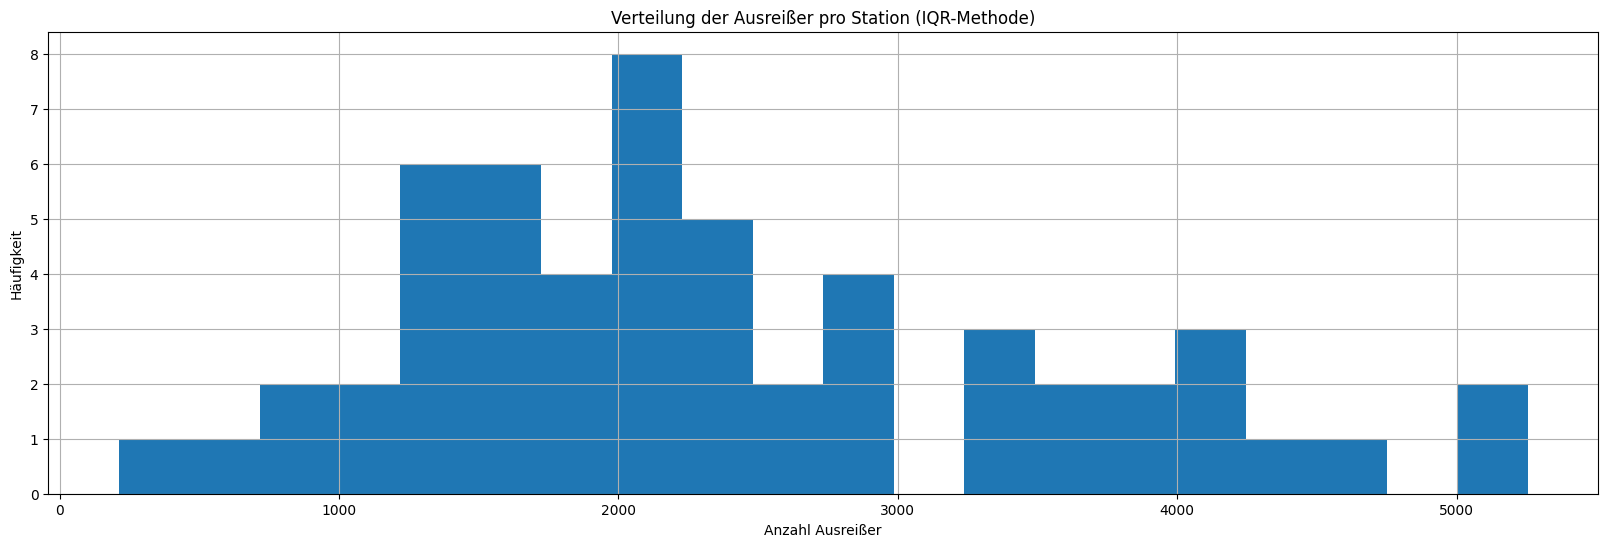


Anzahl Ausreißer pro Station (IQR-Methode):
1078    5254
3028    5191
1544    4704
2014    4473
4745    4214
4371    4198
691     4125
2044    3980
222     3838
198     3681
1605    3510
4642    3473
3811    3420
591     3280
3196    2941
2925    2931
1001    2908
5142    2822
298     2571
3126    2519
2794    2418
164     2397
4625    2357
1420    2328
3761    2270
1869    2221
5629    2155
867     2148
5546    2131
5440    2090
1684    2007
1757    1996
880     1992
2559    1967
427     1965
5705    1884
656     1776
853     1703
3987    1668
4466    1634
596     1583
1468    1580
1262    1562
3366    1454
3231    1450
3015    1447
4501    1423
2638    1396
5397    1346
840     1134
3513     983
2985     833
1550     740
1358     713
183      211
dtype: int64


In [8]:
# 3.4 Ausreißererkennung mit IQR-Methode (statistische Ausreißer)
iqr_outliers = {}

for station in df.columns:
    # Nur numerische Spalten berücksichtigen
    if pd.api.types.is_numeric_dtype(df[station]):
        Q1 = df[station].quantile(0.25)
        Q3 = df[station].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        mask_outliers = (df[station] < lower_bound) | (df[station] > upper_bound)
        iqr_outliers[station] = mask_outliers.sum()

iqr_outlier_series = pd.Series(iqr_outliers)

#Übersichtliche Histogramm-Visualisierung der Ausreißerverteilung
plt.figure(figsize=(20,6))
iqr_outlier_series[iqr_outlier_series > 0].hist(bins=20)
plt.title("Verteilung der Ausreißer pro Station (IQR-Methode)")
plt.xlabel("Anzahl Ausreißer")
plt.ylabel("Häufigkeit")
plt.show()

print("\nAnzahl Ausreißer pro Station (IQR-Methode):")
print(iqr_outlier_series[iqr_outlier_series > 0].sort_values(ascending=False))

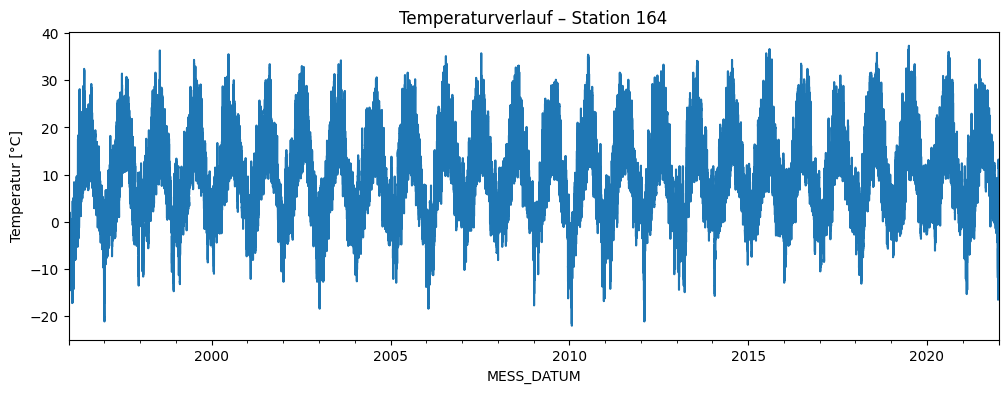

In [9]:
#Erste visuelle Kontrolle
station = [c for c in df.columns if c.isdigit()][0]
plt.figure(figsize=(12, 4))
df[station].plot()
plt.title(f"Temperaturverlauf – Station {station}")
plt.xlabel("MESS_DATUM")
plt.ylabel("Temperatur [°C]")
plt.show()

## Schritt 3: Beantwortung der Forschungsfragen

### Die Forschungsfragen lassen sich zu Ebenen zusammenfassen:

**1. Langfristige Trends:**
- 1.1 Wie hat sich das Wetter über Jahre verändert?
- 1.2 Hat sich die Durchschnittstemperatur über die Jahre erhöht?

**2. Räumliche Unterschiede:**
- 2.1 Gibt es regionale Unterschiede in den Temperaturen?
- 2.2 Welche Stationen haben die höchsten/niedrigsten Temperaturen?
- 2.3 Gibt es Stationen mit regelmäßigen Ausreißern?
- 2.4 Gibt es Extreme zwischen Stationen?

**3. Zeitliche Muster:**
- 3.1 Wie verändert sich die Temperatur im Tagesverlauf im Schnitt pro Stunde?
- 3.2 Wie stark schwanken die Temperaturen innerhalb eines Tages/Monats?
- 3.3 Gibt es jahreszeitliche Trends?

## 1. Langfristige Trends
### 1.1 Wie hat sich Wetter verändert über Jahre verändert?
### 1.2 Hat sich die Durchschnittstemperatur über die Jahre erhöht?

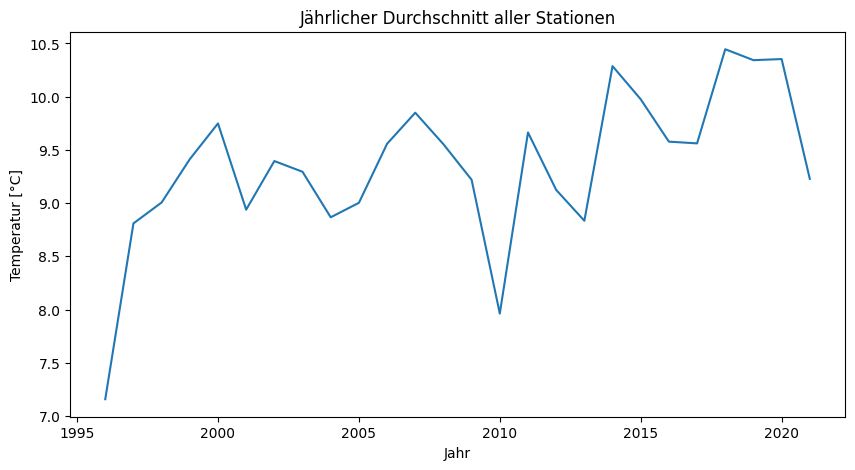

In [10]:
df_yearly = df.groupby('Jahr').mean(numeric_only=True)

plt.figure(figsize=(10,5))
plt.plot(df_yearly.mean(axis=1))
plt.title("Jährlicher Durchschnitt aller Stationen")
plt.ylabel("Temperatur [°C]")
plt.xlabel("Jahr")
plt.show()

**Interpretation:**
Aus dem erstellten Graphen kann man erkennen, dass sich die Durchschnittstemperaturen leicht verändern und sich ungefähr im Bereich 9°C und 10,5°C halten.
Insgesamt steigen die Durchschnittstemperaturen langsam, aber kontinuierlich an, was auf eine langfristige Erwärmung hindeutet. Gleichzeitig gibt ungefähr 
alle zwei Jahre eine Abkühlung der Temperaturen. Besonders auffällig ist ein deutlicher Temperaturabfall im Jahre 2010, der aus ungewöhnlichen 
Wetterereignissen oder spezifischen Jahresanomalien resultieren könnte. Trotz dieser Schwankungen liegt der letzte Messpunkt deutlich über den ersten, 
welches den langfristigen Erwärmungstrend aufzeigt.

## 2. Räumliche Unterschiede
### 2.1 Gibt es regionale Unterschiede in den Temperaturen?


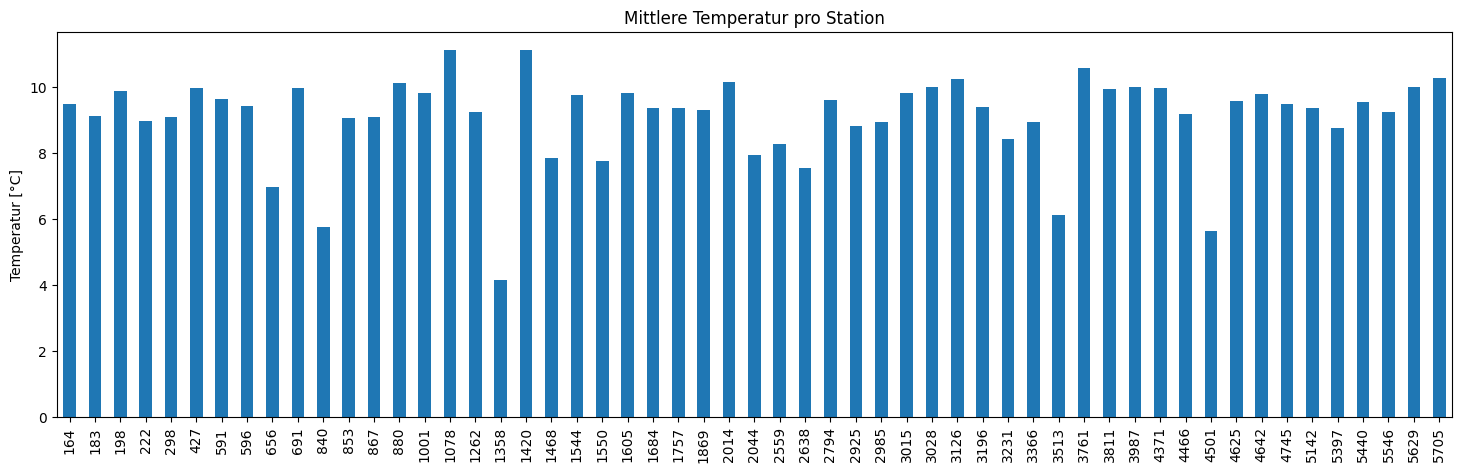

164      9.47
183      9.10
198      9.87
222      8.97
298      9.07
427      9.96
591      9.62
596      9.40
656      6.95
691      9.97
840      5.74
853      9.05
867      9.08
880     10.10
1001     9.81
1078    11.10
1262     9.23
1358     4.14
1420    11.11
1468     7.85
1544     9.76
1550     7.75
1605     9.80
1684     9.34
1757     9.36
1869     9.28
2014    10.13
2044     7.94
2559     8.27
2638     7.53
2794     9.59
2925     8.79
2985     8.93
3015     9.81
3028     9.99
3126    10.23
3196     9.39
3231     8.42
3366     8.92
3513     6.10
3761    10.56
3811     9.94
3987     9.98
4371     9.97
4466     9.18
4501     5.62
4625     9.58
4642     9.77
4745     9.47
5142     9.35
5397     8.74
5440     9.53
5546     9.23
5629    10.00
5705    10.26
dtype: float64

In [11]:
station_means = df.drop(columns=["Datum", "Uhrzeit", "Jahr", "Monat", "Tag", "Stunde", "Minute", "Wochentag", "Jahreszeit"]).select_dtypes("number").mean()

station_means.plot(kind='bar', figsize=(18,5))
plt.title("Mittlere Temperatur pro Station")
plt.ylabel("Temperatur [°C]")
plt.show()

station_means.round(2)

**Interpretation:**
Die meisten Stationen liegen im mittleren Temperaturbereich zwischen rund 8 °C und 10 °C, was auf ähnliche klimatische Bedingungen an vielen Messorten hindeutet. Einige Stationen weichen jedoch deutlich von diesem Bereich ab, was meist durch geografische Faktoren wie Höhenlage erklärbar ist. So liegt die Station 1358 am Fichtelberg auf 1213 m Höhe und weist entsprechend niedrigere Mittelwerte auf, während die Station 1420 in Frankfurt am Main mit nur 112 m Höhe deutlich wärmere Durchschnittstemperaturen erreicht. Solche Unterschiede entsprechen typischen Temperatureffekten durch Höhe und regionale Lage. (Quelle der Höhen: https://www.dwd.de/DE/leistungen/klimadatendeutschland/stationsuebersicht.html)

### 2.2 Welche Stationen haben die niedrigsten und höchsten Temperaturen?

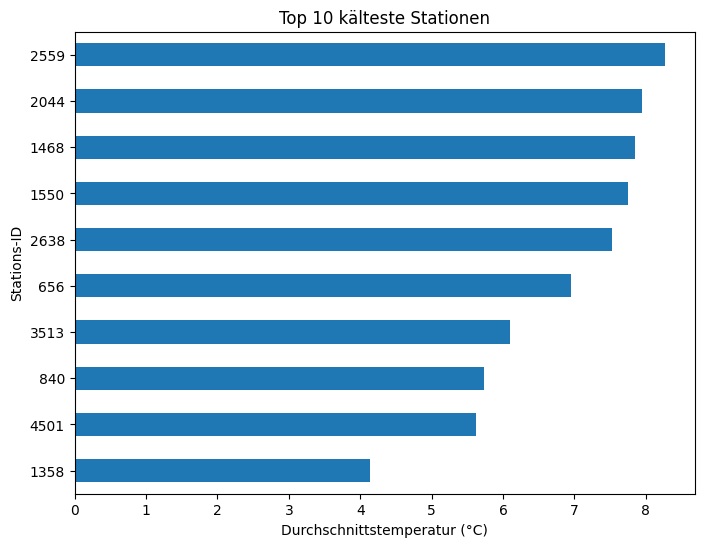

1358    4.1
4501    5.6
840     5.7
3513    6.1
656     7.0
2638    7.5
1550    7.8
1468    7.8
2044    7.9
2559    8.3
dtype: float64


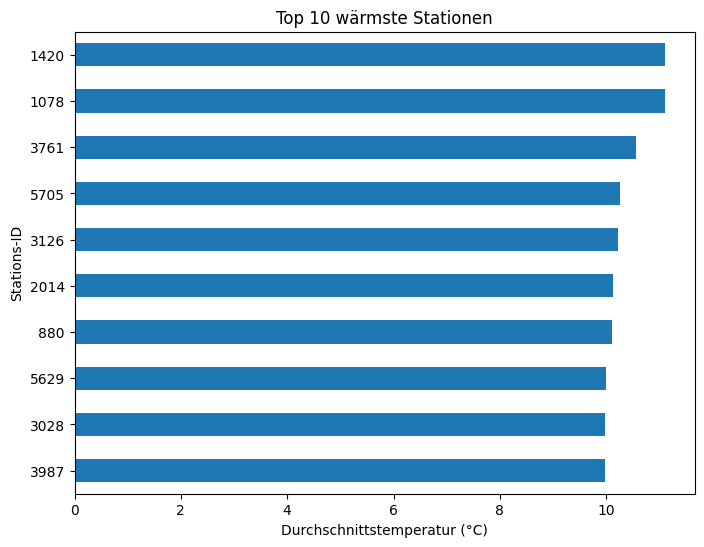

3987    10.0
3028    10.0
5629    10.0
880     10.1
2014    10.1
3126    10.2
5705    10.3
3761    10.6
1078    11.1
1420    11.1
dtype: float64


In [12]:
mean_per_station = df[station_cols].mean().sort_values()

mean_per_station.head(10).plot(kind='barh', figsize=(8, 6))
plt.xlabel("Durchschnittstemperatur (°C)")
plt.ylabel("Stations-ID")
plt.title("Top 10 kälteste Stationen")
plt.show()
print(mean_per_station.head(10).round(1))

mean_per_station.tail(10).plot(kind='barh', figsize=(8, 6))
plt.xlabel("Durchschnittstemperatur (°C)")
plt.ylabel("Stations-ID")
plt.title("Top 10 wärmste Stationen")
plt.show()
print(mean_per_station.tail(10).round(1))

**Interpretation:**
Die Station 1358 weist die niedrigste Durchschnittstemperatur auf, während die Stationen 1078 und 1420 die höchsten Mittelwerte erreichen. Bei den zehn wärmsten Stationen liegen die Temperaturen eng beieinander (zwischen 10,0 °C und 11,1 °C), was auf sehr ähnliche klimatische Bedingungen schließen lässt. Die zehn kältesten Stationen zeigen dagegen eine deutlich größere Spannweite von 4,1 °C bis 8,3 °C, wobei der Temperaturabfall zur kältesten Station hin deutlich stärker ausfällt. Diese größere Streuung deutet darauf hin, dass die kälteren Stationen stärker durch geografische Faktoren wie Höhenlage beeinflusst werden. Insgesamt spiegeln die Unterschiede zwischen den Stationen typische klimatische Gradienten wider, insbesondere den Einfluss der Höhe auf die gemessene Temperatur.

### 2.3 Gibt es Stationen mit regelmäßigen Ausreißern?
### 2.4 Gibt es Extreme zwischen Stationen?

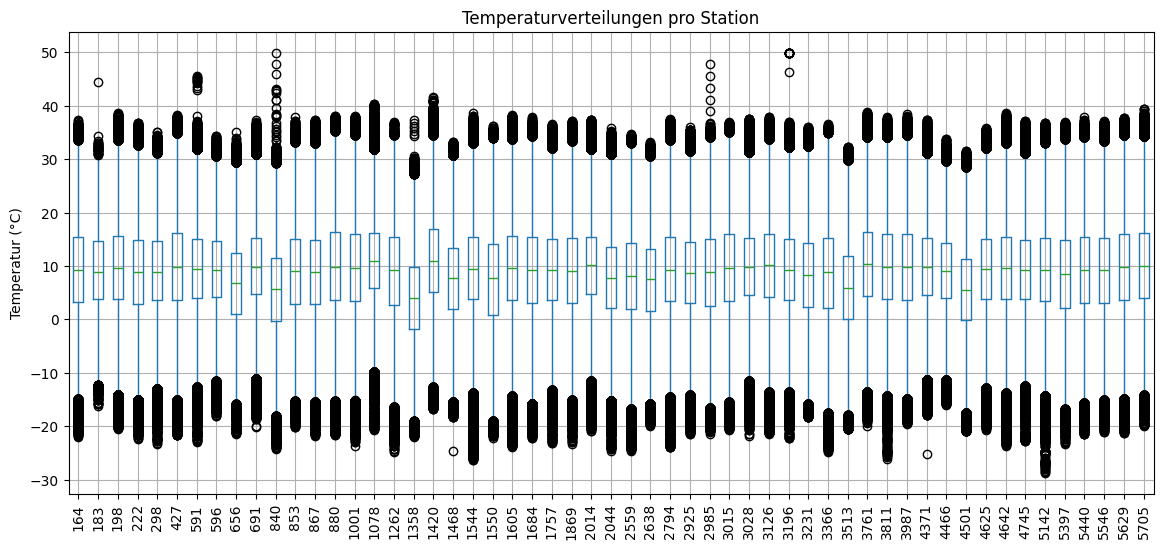

In [13]:
station_cols = [col for col in df.columns if col.isdigit()]

plt.figure(figsize=(14, 6))
df[station_cols].boxplot(rot=90)
plt.title("Temperaturverteilungen pro Station")
plt.ylabel("Temperatur (°C)")
plt.show()

**Interpretation:**
Aus der Datenreinigung kann man entnehmen, dass die Station 1078 mit 5254 Ausreißern die meisten hat, kurz danach gefolgt von Station 3028 mit 5191 Ausreißern. Die Station 183 hat mit 211 Ausreißern die wenigsten. Man kann sehen, dass alle Stationen Ausreißer haben. Die Stationen 840, 2985 und 591 haben auffällig viele Ausreißer bei wärmeren Temperaturen. Dies kann ebenfalls standortbedingt sein. Währenddessen haben die Stationen 1078, 1544, 3811 und 5142 auffällig viele Ausreißer bei niedrigen Temperaturen. Dies kann aufgrund der geographischen Lage der Stationen sein.
Die meisten Stationen haben einen Median von 8°C-10°C. Die Stationen 1078 und 1420 haben Mediane über 10°C. Diese liegen an wärmeren Orten als der Rest. Die Stationen 656, 840, 1358, 2638, 3513 und 4501 haben Mediane die unter 8°C liegen. Diese stellen Extreme für untere Temperaturen dar und diese Stationen liegen an kälteren Standorten als der Rest.

## 3. Zeitliche Muster
### 3.1 Wie verändert sich die Temperatur im Tagesverlauf im Schnitt pro Stunde?

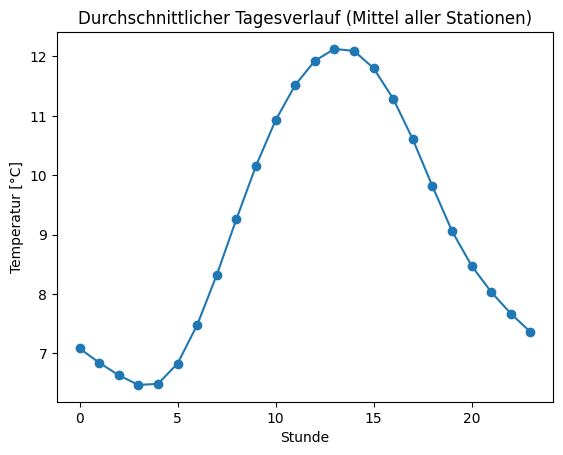

MESS_DATUM
0      7.1
1      6.8
2      6.6
3      6.5
4      6.5
5      6.8
6      7.5
7      8.3
8      9.3
9     10.2
10    10.9
11    11.5
12    11.9
13    12.1
14    12.1
15    11.8
16    11.3
17    10.6
18     9.8
19     9.1
20     8.5
21     8.0
22     7.7
23     7.4
dtype: float64


In [14]:
hourly_mean_by_station = df[station_cols].groupby(df.index.hour).mean()
#global hourly mean:
global_hourly_mean = hourly_mean_by_station.mean(axis=1)


plt.figure()
global_hourly_mean.plot(marker='o')
plt.title('Durchschnittlicher Tagesverlauf (Mittel aller Stationen)')
plt.xlabel('Stunde')
plt.ylabel('Temperatur [°C]')
plt.show()

print(global_hourly_mean.round(1))

**Interpretation:**
Der durchschnittliche Tagesverlauf zeigt, dass die Temperaturen ab den frühen Morgenstunden kontinuierlich ansteigen und ihren Höhepunkt gegen 13–14 Uhr erreichen. Anschließend sinken sie stetig bis in die Nacht. Der tiefste Temperaturpunkt tritt typischerweise gegen 3 Uhr auf, bevor die Temperaturen mit Sonnenaufgang wieder ansteigen. Dieses Muster entspricht dem typischen tageszeitlichen Erwärmungs- und Abkühlungsprozess.

### 3.2 Wie stark schwanken die Temperaturen innerhalb eines Tages bzw. Monats?

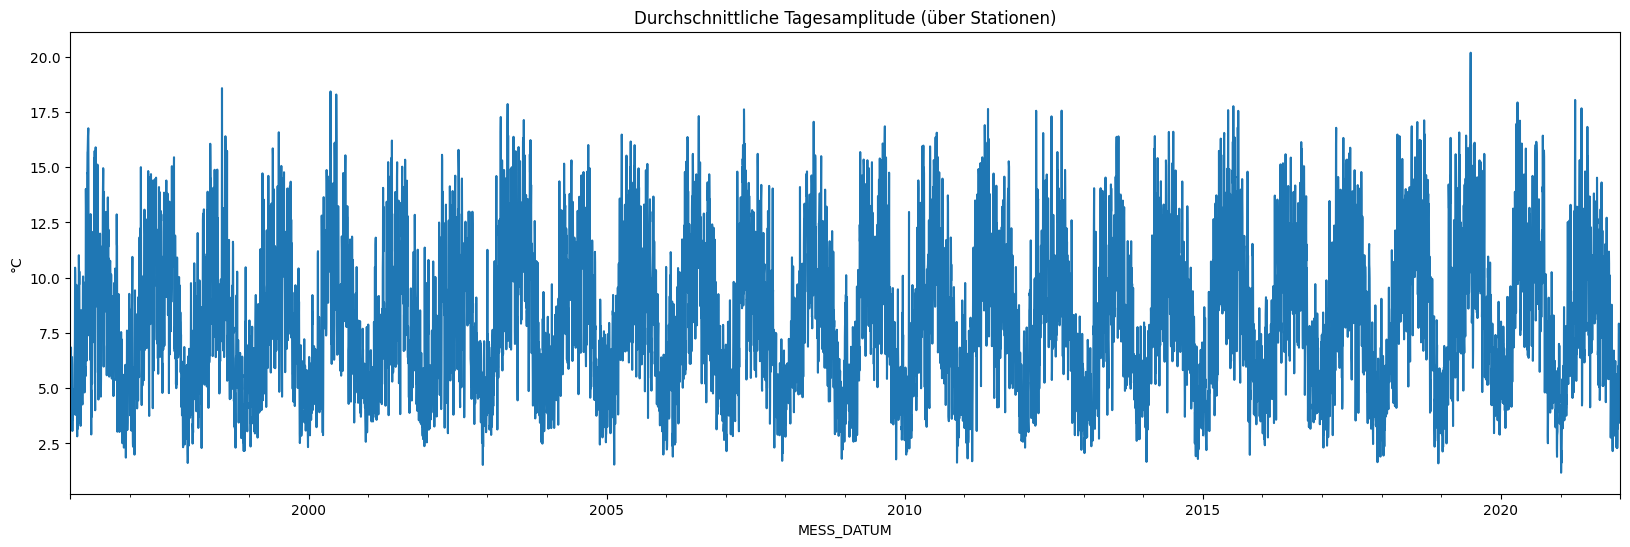

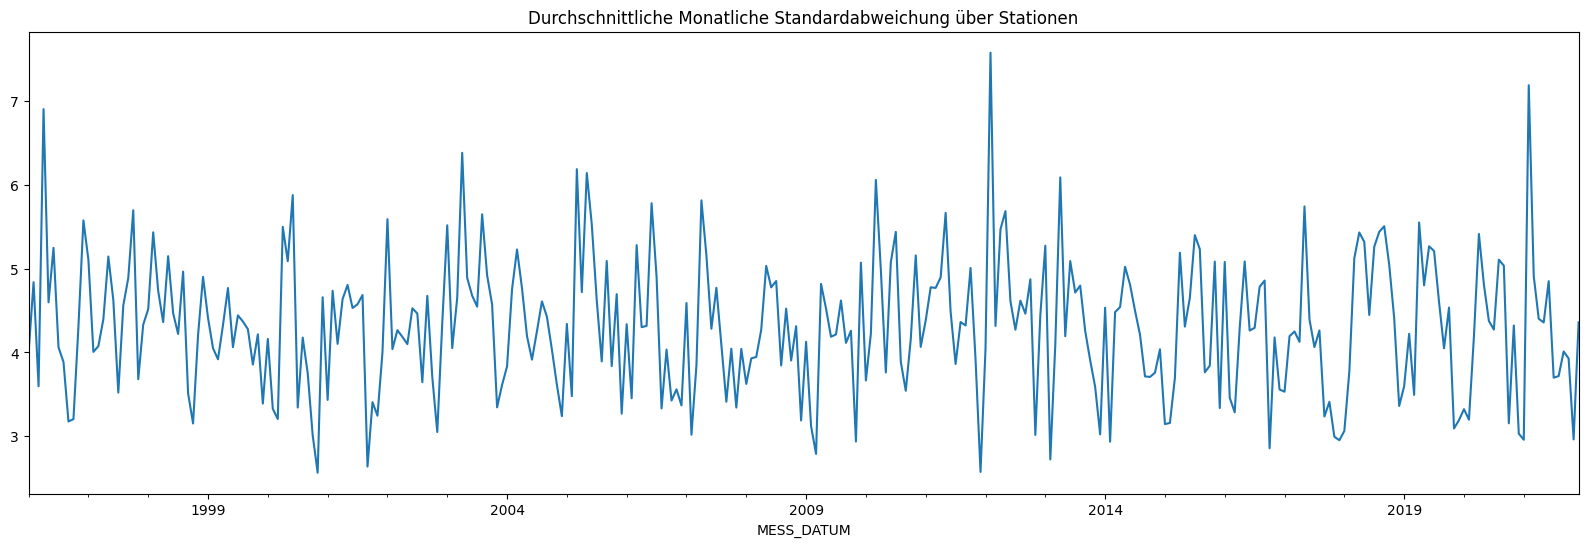

In [15]:
# Tagesamplitude pro Tag = max - min pro Tag (pro Station oder gemittelt)
daily_range = df[station_cols].resample('D').agg(lambda x: x.max()-x.min())
daily_range_mean = daily_range.mean(axis=1)
plt.figure(figsize=(20,6))
daily_range_mean.plot(title='Durchschnittliche Tagesamplitude (über Stationen)')
plt.ylabel('°C')
plt.show()

# Monatsweise Standardabweichung
monthly_std = df[station_cols].resample('ME').std().mean(axis=1)
plt.figure(figsize=(20,6))
monthly_std.plot(title='Durchschnittliche Monatliche Standardabweichung über Stationen')
plt.show()


**Interpretation:**
Der erste Graph zeigt eine klar wellenförmige Kurve, bei der die Tagesamplitude regelmäßig zwischen Tief- und Hochpunkten schwankt. Die Amplitude erreicht im Jahresverlauf im Frühling ihre Höchstwerte, während sie im Winter deutlich niedriger ausfällt.
Dieses Muster spiegelt den Einfluss der Jahreszeiten wider: Im Frühling werden die Tage länger und die Sonneneinstrahlung stärker, sodass sich die Temperaturtagsgänge vergrößern. Im Winter hingegen sind kürzere Tage und geringere Sonneneinstrahlung für kleinere Tagesamplituden verantwortlich. Insgesamt zeigt die Kurve, dass die Temperaturschwankungen zwischen Tag und Nacht über das Jahr hinweg recht konstant und über die Jahreszeiten hinweg gut nachvollziehbar sind.

Die zweite Graph beschreibt, wie stark die Temperaturen innerhalb eines Monats schwanken. Höhere Werte weisen auf Monate hin, in denen die Temperatur stärker variiert, normalerweise im Frühling und Herbst. Niedrige Werte treten typischerweise im Hochsommer und Hochwinter auf, wenn das Wetter stabiler ist. Die Graph zeigt damit gut, in welchen Jahreszeiten die Temperaturschwankungen besonders groß bzw. besonders gering sind.

### 3.3 Gibt es jahreszeitliche Trends?

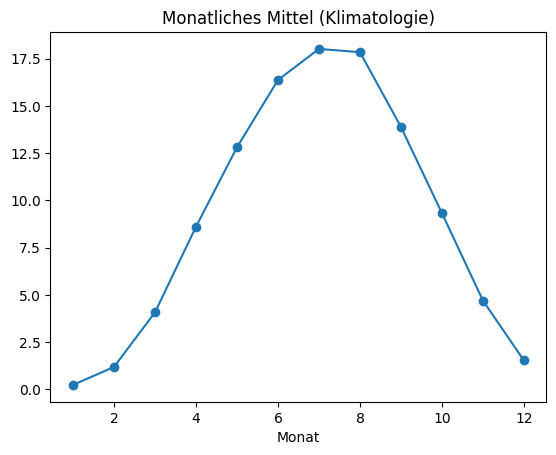

MESS_DATUM
1      0.2
2      1.2
3      4.1
4      8.6
5     12.8
6     16.4
7     18.0
8     17.8
9     13.9
10     9.3
11     4.7
12     1.5
dtype: float64

In [16]:
df_daily = df[station_cols].resample('D').mean()

monthly_clim = df_daily.groupby(df_daily.index.month).mean().mean(axis=1)
monthly_clim.plot(marker='o', title='Monatliches Mittel (Klimatologie)')
plt.xlabel('Monat')
plt.show()

display(monthly_clim.round(1))

**Interpretation:**
Der Graph zeigt, dass die höchsten Durchschnittstemperaturen im Sommermonat Juli mit etwa 18 °C erreicht werden und danach wieder abfallen. Die niedrigsten Mittelwerte treten im Wintermonat Januar mit rund 0,2 °C auf und steigen in den folgenden Monaten kontinuierlich an. Dieses Muster spiegelt den typischen Verlauf der Jahreszeiten wider, mit warmen Sommer- und kalten Wintermonaten. Insgesamt zeigt der Graph die erwarteten jahreszeitlichen Temperaturschwankungen.